数据集特征维度： (150, 4)
花卉类别： ['setosa' 'versicolor' 'virginica']
模型分类准确率：0.9667
详细分类评估报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40482 (\N{CJK UNIFIED IDEOGRAPH-9E22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

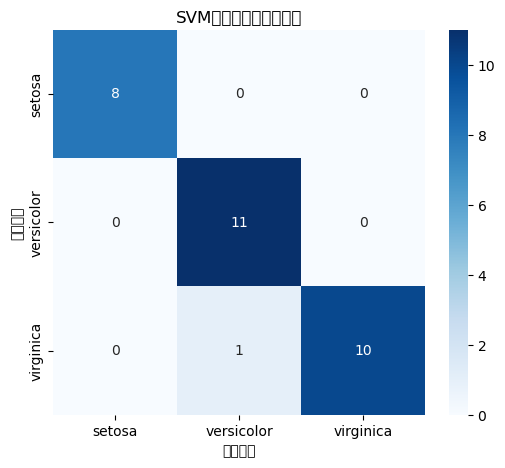

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1.加载鸢尾花数据集
iris = load_iris()
# 花朵特征数据
x_data = iris.data
# 花朵分类标签
y_label = iris.target
# 类别名称
class_name = iris.target_names

print("数据集特征维度：", x_data.shape)
print("花卉类别：", class_name)

# 2.拆分训练数据和测试数据
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_label, test_size=0.2, random_state=20
)

# 3.数据标准化处理
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

# 4.创建并训练SVM分类模型
svm_model = SVC(kernel="linear")
svm_model.fit(x_train_std, y_train)

# 5.模型预测
y_predict = svm_model.predict(x_test_std)

# 6.评估模型效果
acc = accuracy_score(y_test, y_predict)
print("="*40)
print(f"模型分类准确率：{acc:.4f}")
print("="*40)
print("详细分类评估报告：")
print(classification_report(y_test, y_predict, target_names=class_name))

# 7.绘制混淆矩阵图
conf_mat = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, cmap="Blues", 
            xticklabels=class_name, yticklabels=class_name)
plt.xlabel("预测类别")
plt.ylabel("真实类别")
plt.title("SVM鸢尾花分类混淆矩阵")
plt.show()